In [26]:
%env MPLBACKEND=
%matplotlib inline
import pandas as pd
import numpy as np
import pymc as pm
from src.data_utils import load_and_process_data, load_football_data, create_weighted_scoreline_data
from src.model import build_and_sample_model
from src.trace_save_load import load_previous_season_trace, extract_previous_season_priors, save_season_trace
import matplotlib.pyplot as plt

league = ['Premier_League']
season = '2025-2026'



env: MPLBACKEND=


In [35]:
df, team_mapping, n_teams = load_and_process_data(
    db_path=r'/Users/admin/dev/algobetting/infra/data/db/fotmob.db',
    league=league,
    season=season,
    max_goals=9,
    decay_rate=0.04,
    goals_weight=0.25,
    xg_weight=0.5,
    psxg_weight=0.15,
    epv_weight=0.1
)

In [36]:
import pandas as pd

def calculate_weighted_league_stats(weighted_df):
    # 1. Group by Match ID first to get the expected goals FOR EACH GAME
    # This collapses the 100+ scorelines back into one 'Expected Outcome' per match
    match_expectations = weighted_df.groupby('match_id').apply(lambda x: pd.Series({
        'exp_home_goals': (x['home_goals'] * x['weight']).sum() / x['weight'].sum(),
        'exp_away_goals': (x['away_goals'] * x['weight']).sum() / x['weight'].sum(),
        'match_weight': x['weight'].sum() # This handles time decay (usually ~1.0 or less)
    })).reset_index()

    # 2. Calculate League Averages using the collapsed match data
    # We use match_weight to ensure older games count for less in the average
    total_w = match_expectations['match_weight'].sum()
    avg_home_goals = (match_expectations['exp_home_goals'] * match_expectations['match_weight']).sum() / total_w
    avg_away_goals = (match_expectations['exp_away_goals'] * match_expectations['match_weight']).sum() / total_w
    avg_total_goals = avg_home_goals + avg_away_goals

    print("="*40)
    print("CORRECTED WEIGHTED LEAGUE AVERAGES")
    print("="*40)
    print(f"Avg Home Goals:  {avg_home_goals:.3f}")
    print(f"Avg Away Goals:  {avg_away_goals:.3f}")
    print(f"Avg Total Goals: {avg_total_goals:.3f}")
    print("="*40)

    # 3. Individual Team Stats (using the same 'collapsed' match expectations)
    # Join the match expectations back to the original match metadata to get team names
    match_meta = weighted_df[['match_id', 'home_team', 'away_team']].drop_duplicates()
    match_expectations = match_expectations.merge(match_meta, on='match_id')

    home_stats = match_expectations.groupby('home_team').apply(lambda x: pd.Series({
        'gf': (x['exp_home_goals'] * x['match_weight']).sum(),
        'ga': (x['exp_away_goals'] * x['match_weight']).sum(),
        'w': x['match_weight'].sum()
    }))

    away_stats = match_expectations.groupby('away_team').apply(lambda x: pd.Series({
        'gf': (x['exp_away_goals'] * x['match_weight']).sum(),
        'ga': (x['exp_home_goals'] * x['match_weight']).sum(),
        'w': x['match_weight'].sum()
    }))

    # Final Team Table
    team_stats = pd.DataFrame(index=home_stats.index)
    # Penalty baselines (from analysis)
    BASELINE_HOME_PENS = 0.157 * 0.78
    BASELINE_AWAY_PENS = 0.101 * 0.78
    team_stats['gf_avg'] = ((home_stats['gf'] + away_stats['gf']) / (home_stats['w'] + away_stats['w'])) + ((BASELINE_HOME_PENS + BASELINE_AWAY_PENS)/2)
    team_stats['ga_avg'] = ((home_stats['ga'] + away_stats['ga']) / (home_stats['w'] + away_stats['w'])) + ((BASELINE_HOME_PENS + BASELINE_AWAY_PENS)/2)
    team_stats['net_rating'] = team_stats['gf_avg'] - team_stats['ga_avg']

    return team_stats.sort_values('net_rating', ascending=False)

# Execute
team_ratings = calculate_weighted_league_stats(df)
print(team_ratings)

CORRECTED WEIGHTED LEAGUE AVERAGES
Avg Home Goals:  1.276
Avg Away Goals:  1.155
Avg Total Goals: 2.431
                gf_avg  ga_avg  net_rating
home_team                                 
Arsenal           1.75    0.87        0.88
Man City          1.80    1.02        0.77
Liverpool         1.76    1.16        0.60
Chelsea           1.78    1.26        0.52
Man United        1.54    1.08        0.46
Brentford         1.70    1.38        0.31
Brighton          1.20    0.91        0.29
Bournemouth       1.44    1.21        0.23
Fulham            1.18    1.14        0.04
Crystal Palace    1.01    1.02       -0.01
Newcastle         1.40    1.46       -0.06
Leeds             1.03    1.11       -0.08
Everton           1.26    1.49       -0.23
West Ham          1.27    1.50       -0.23
Nottm Forest      1.00    1.38       -0.38
Tottenham         1.17    1.71       -0.54
Sunderland        0.78    1.37       -0.59
Aston Villa       1.17    1.76       -0.59
Wolves            1.09    1.68      

In [37]:
df[df["match_id"] == 4813589]["weight"].sum()

np.float64(0.09827358560436154)

In [4]:
import pandas as pd

# 1. Create two small dataframes for Home and Away occurrences
home_matches = df[['match_id', 'home_team']].rename(columns={'home_team': 'team'})
away_matches = df[['match_id', 'away_team']].rename(columns={'away_team': 'team'})

# 2. Stack them on top of each other
all_match_appearances = pd.concat([home_matches, away_matches])

# 3. Group by team and count unique Match IDs
match_counts = all_match_appearances.groupby('team')['match_id'].nunique().reset_index()

# 4. Rename for clarity
match_counts.columns = ['Team', 'Matches_Played']

print(match_counts.sort_values(by='Matches_Played', ascending=False))


              Team  Matches_Played
0          Arsenal              31
19          Wolves              31
2      Bournemouth              30
3        Brentford              30
18        West Ham              30
17       Tottenham              30
16      Sunderland              30
15    Nottm Forest              30
14       Newcastle              30
13      Man United              30
12        Man City              30
11       Liverpool              30
1      Aston Villa              30
9           Fulham              30
8          Everton              30
7   Crystal Palace              30
6          Chelsea              30
5          Burnley              30
4         Brighton              30
10           Leeds              30


In [5]:
df[df["match_id"] == 4813374]["weight"].sum()

np.float64(0.014122302410163962)

In [6]:
model, trace = build_and_sample_model(
     df, 
     n_teams, 
     team_mapping=team_mapping,
     trace=20000,
     tune=10000
 )

There were 69 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


                  mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
att_str_raw[0]   0.029  0.101  -0.140    0.264      0.005    0.005     663.0    1195.0   1.04
att_str_raw[1]   0.007  0.100  -0.196    0.214      0.007    0.005      99.0    1253.0   1.03
att_str_raw[2]   0.014  0.098  -0.170    0.223      0.002    0.005     185.0    1135.0   1.02
att_str_raw[3]   0.065  0.169  -0.119    0.461      0.062    0.060      15.0    1903.0   1.19
att_str_raw[4]  -0.024  0.106  -0.218    0.182      0.018    0.004      32.0    1039.0   1.08
att_str_raw[5]  -0.020  0.103  -0.247    0.152      0.006    0.005     134.0    1352.0   1.03
att_str_raw[6]   0.080  0.173  -0.101    0.496      0.065    0.064      15.0    1746.0   1.19
att_str_raw[7]   0.009  0.124  -0.198    0.227      0.035    0.020      17.0    1258.0   1.16
att_str_raw[8]  -0.010  0.092  -0.204    0.175      0.001    0.004    3948.0    1174.0   1.05
att_str_raw[9]  -0.011  0.099  -0.220    0.181      0.002   

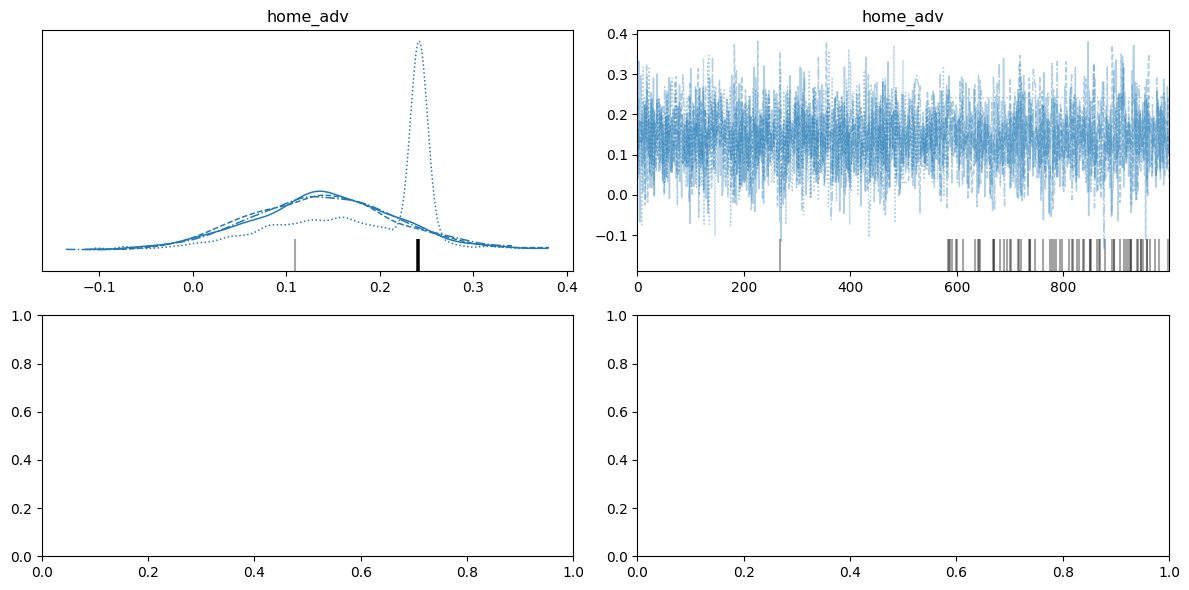

In [7]:
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd

# Quick summary - full table display with 2 decimal places
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)  # Prevents wrapping
pd.set_option('display.precision', 3)  # 2 decimal places

summary = az.summary(trace)
print(summary)

# Quick plots
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Trace plots for key parameters
az.plot_trace(trace, var_names=['home_adv'], axes=axes)
plt.tight_layout()
plt.show()


In [8]:
# --- DEFENSE DATA EXTRACTION ---
def_means = []
def_stds = []
def_team_names = []

for i in range(20):
    team_name = [k for k, v in team_mapping.items() if v == i][0]
    def_means.append(summary.loc[f'def_str[{i}]', 'mean'])
    def_stds.append(summary.loc[f'def_str[{i}]', 'sd'])
    def_team_names.append(team_name)

# Create list of tuples and sort
# For defense, lower mean = better defense. 
# Sorting ascending [lowest -> highest] means best defense is first in the list.
def_data = list(zip(def_means, def_stds, def_team_names))
def_data_sorted = sorted(def_data, key=lambda x: x[0])  

# Extract sorted components
sorted_def_means = [x[0] for x in def_data_sorted]
sorted_def_stds = [x[1] for x in def_data_sorted]
sorted_def_names = [x[2] for x in def_data_sorted]


# --- ATTACK DATA EXTRACTION ---
att_means = []
att_stds = []
att_team_names = []

for i in range(20):
    team_name = [k for k, v in team_mapping.items() if v == i][0]
    att_means.append(summary.loc[f'att_str[{i}]', 'mean'])
    att_stds.append(summary.loc[f'att_str[{i}]', 'sd'])
    att_team_names.append(team_name)

# Create list of tuples and sort
# For attack, higher mean = better attack.
# Sorting descending [highest -> lowest] means best attack is first in the list.
att_data = list(zip(att_means, att_stds, att_team_names))
att_data_sorted = sorted(att_data, key=lambda x: x[0], reverse=True)  

# Extract sorted components
sorted_att_means = [x[0] for x in att_data_sorted]
sorted_att_stds = [x[1] for x in att_data_sorted]
sorted_att_names = [x[2] for x in att_data_sorted]

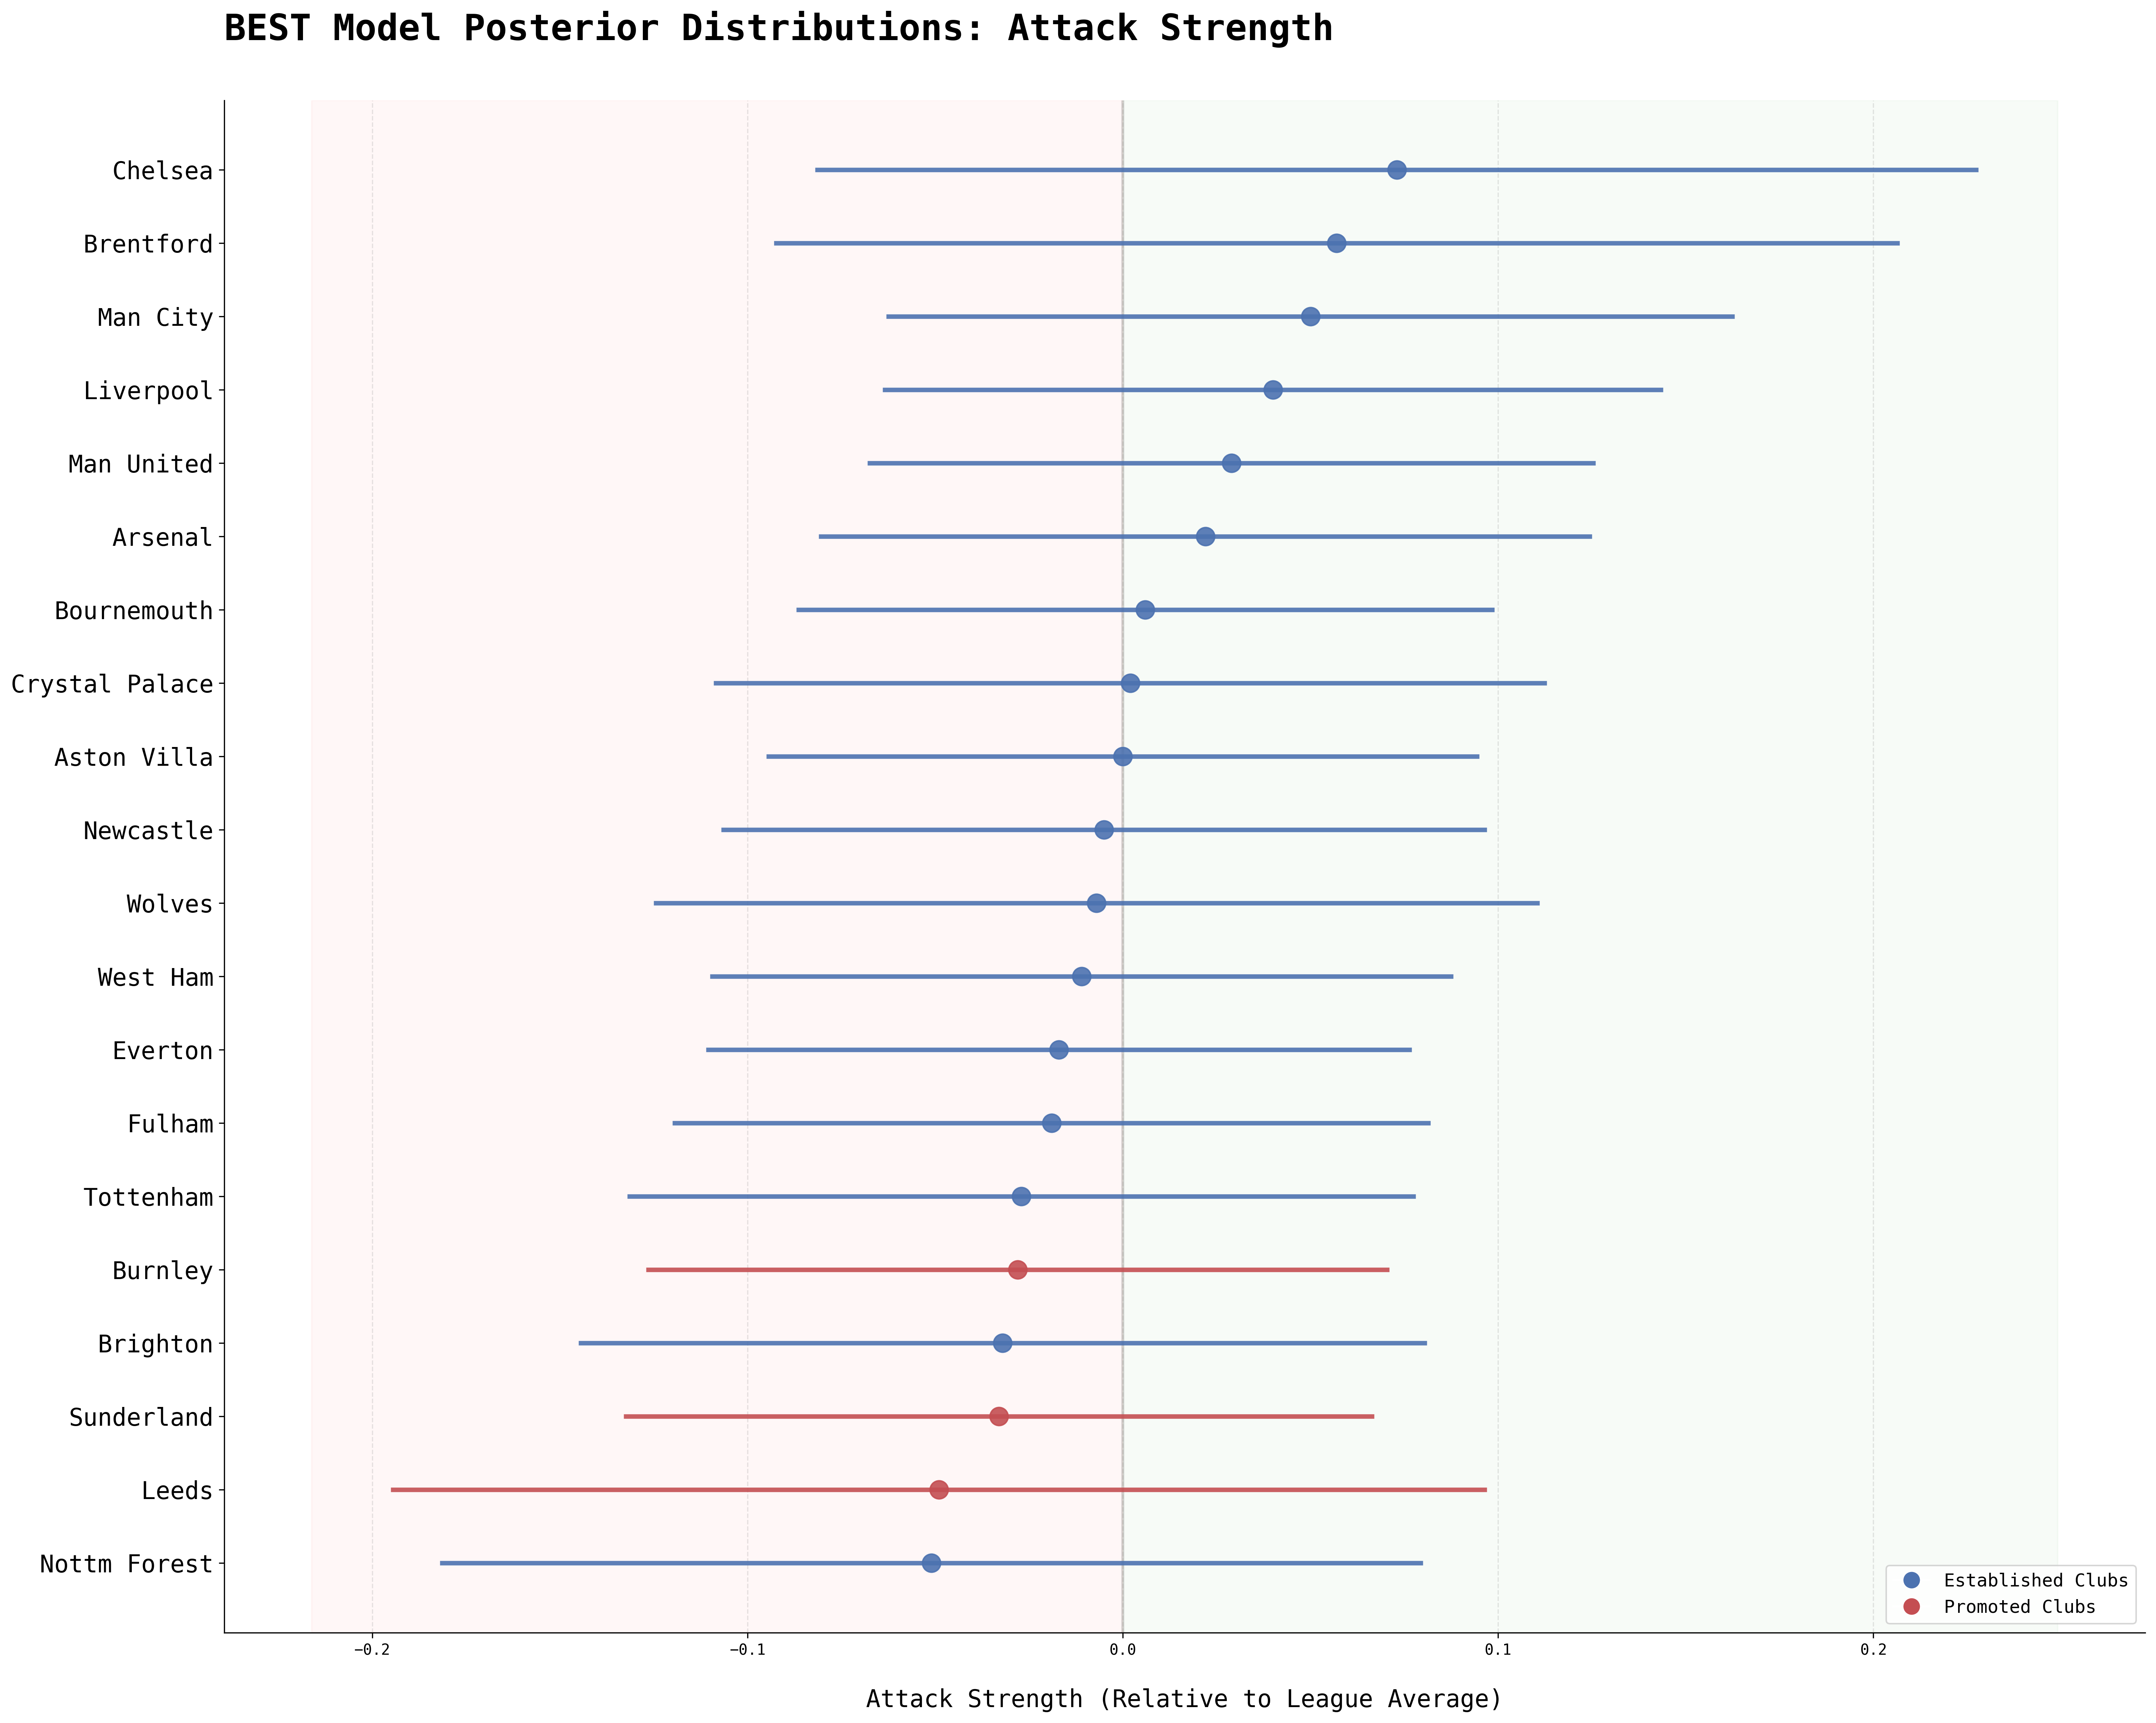

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from style import StyleConfig

# 1. Apply the Configuration
StyleConfig.apply_style()

# 2. Setup Figure
fig, ax = plt.subplots(figsize=StyleConfig.PLOT['figure_size'])
ax.set_facecolor('white')

# 3. Preparation
promoted_teams = ['Burnley', 'Leeds', 'Sunderland']
n_teams = len(sorted_att_names)
y_positions = list(range(n_teams))

# Colors from StyleConfig palette
existing_color = sns.color_palette(StyleConfig.COLORS['palette'])[0] 
promoted_color = sns.color_palette(StyleConfig.COLORS['palette'])[3] 

# 4. Plotting
for i, (mean, std, name) in enumerate(zip(sorted_att_means, sorted_att_stds, sorted_att_names)):
    is_promoted = name in promoted_teams
    current_color = promoted_color if is_promoted else existing_color
    
    # Best teams at the top
    y_pos = n_teams - 1 - i
    
    ax.errorbar(
        mean, y_pos, xerr=std, 
        fmt='o', 
        markersize=12,
        capsize=0,           
        color=current_color, 
        ecolor=current_color,
        elinewidth=3,        # Thicker for better visibility
        alpha=StyleConfig.PLOT['alpha'],
        zorder=3
    )

# 5. Axes & Labels (Restoring the Y-Axis)
ax.set_yticks(y_positions)
# We use reversed names because index 0 is at the bottom of the plot
ax.set_yticklabels(reversed(sorted_att_names), fontsize=StyleConfig.FONTS['label_size'])

ax.set_xlabel('Attack Strength (Relative to League Average)', fontsize=StyleConfig.FONTS['label_size'], labelpad=20)
ax.set_title('BEST Model Posterior Distributions: Attack Strength', 
             fontsize=StyleConfig.FONTS['title_size'], 
             pad=40, loc='left', weight='bold')

# 6. Styling Refinements
# Vertical average line
ax.axvline(x=0, color=StyleConfig.COLORS['axis_color'], linestyle='-', linewidth=2, alpha=0.3, zorder=1)

# Subtle background shading for "Above Average"
xmin, xmax = ax.get_xlim()
ax.axvspan(0, xmax, color='green', alpha=0.03, zorder=0)
ax.axvspan(xmin, 0, color='red', alpha=0.03, zorder=0)

# Grid & Spines
ax.grid(axis='x', color=StyleConfig.COLORS['grid_color'], linestyle='--', alpha=0.2, zorder=1)
sns.despine(left=False, bottom=False)

# 7. Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=existing_color, markersize=12, label='Established Clubs'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=promoted_color, markersize=12, label='Promoted Clubs')
]

ax.legend(
    handles=legend_elements, 
    loc='lower right', 
    fontsize=StyleConfig.FONTS['legend_size'],
    frameon=True,
    facecolor='white'
)

plt.tight_layout()
plt.show()

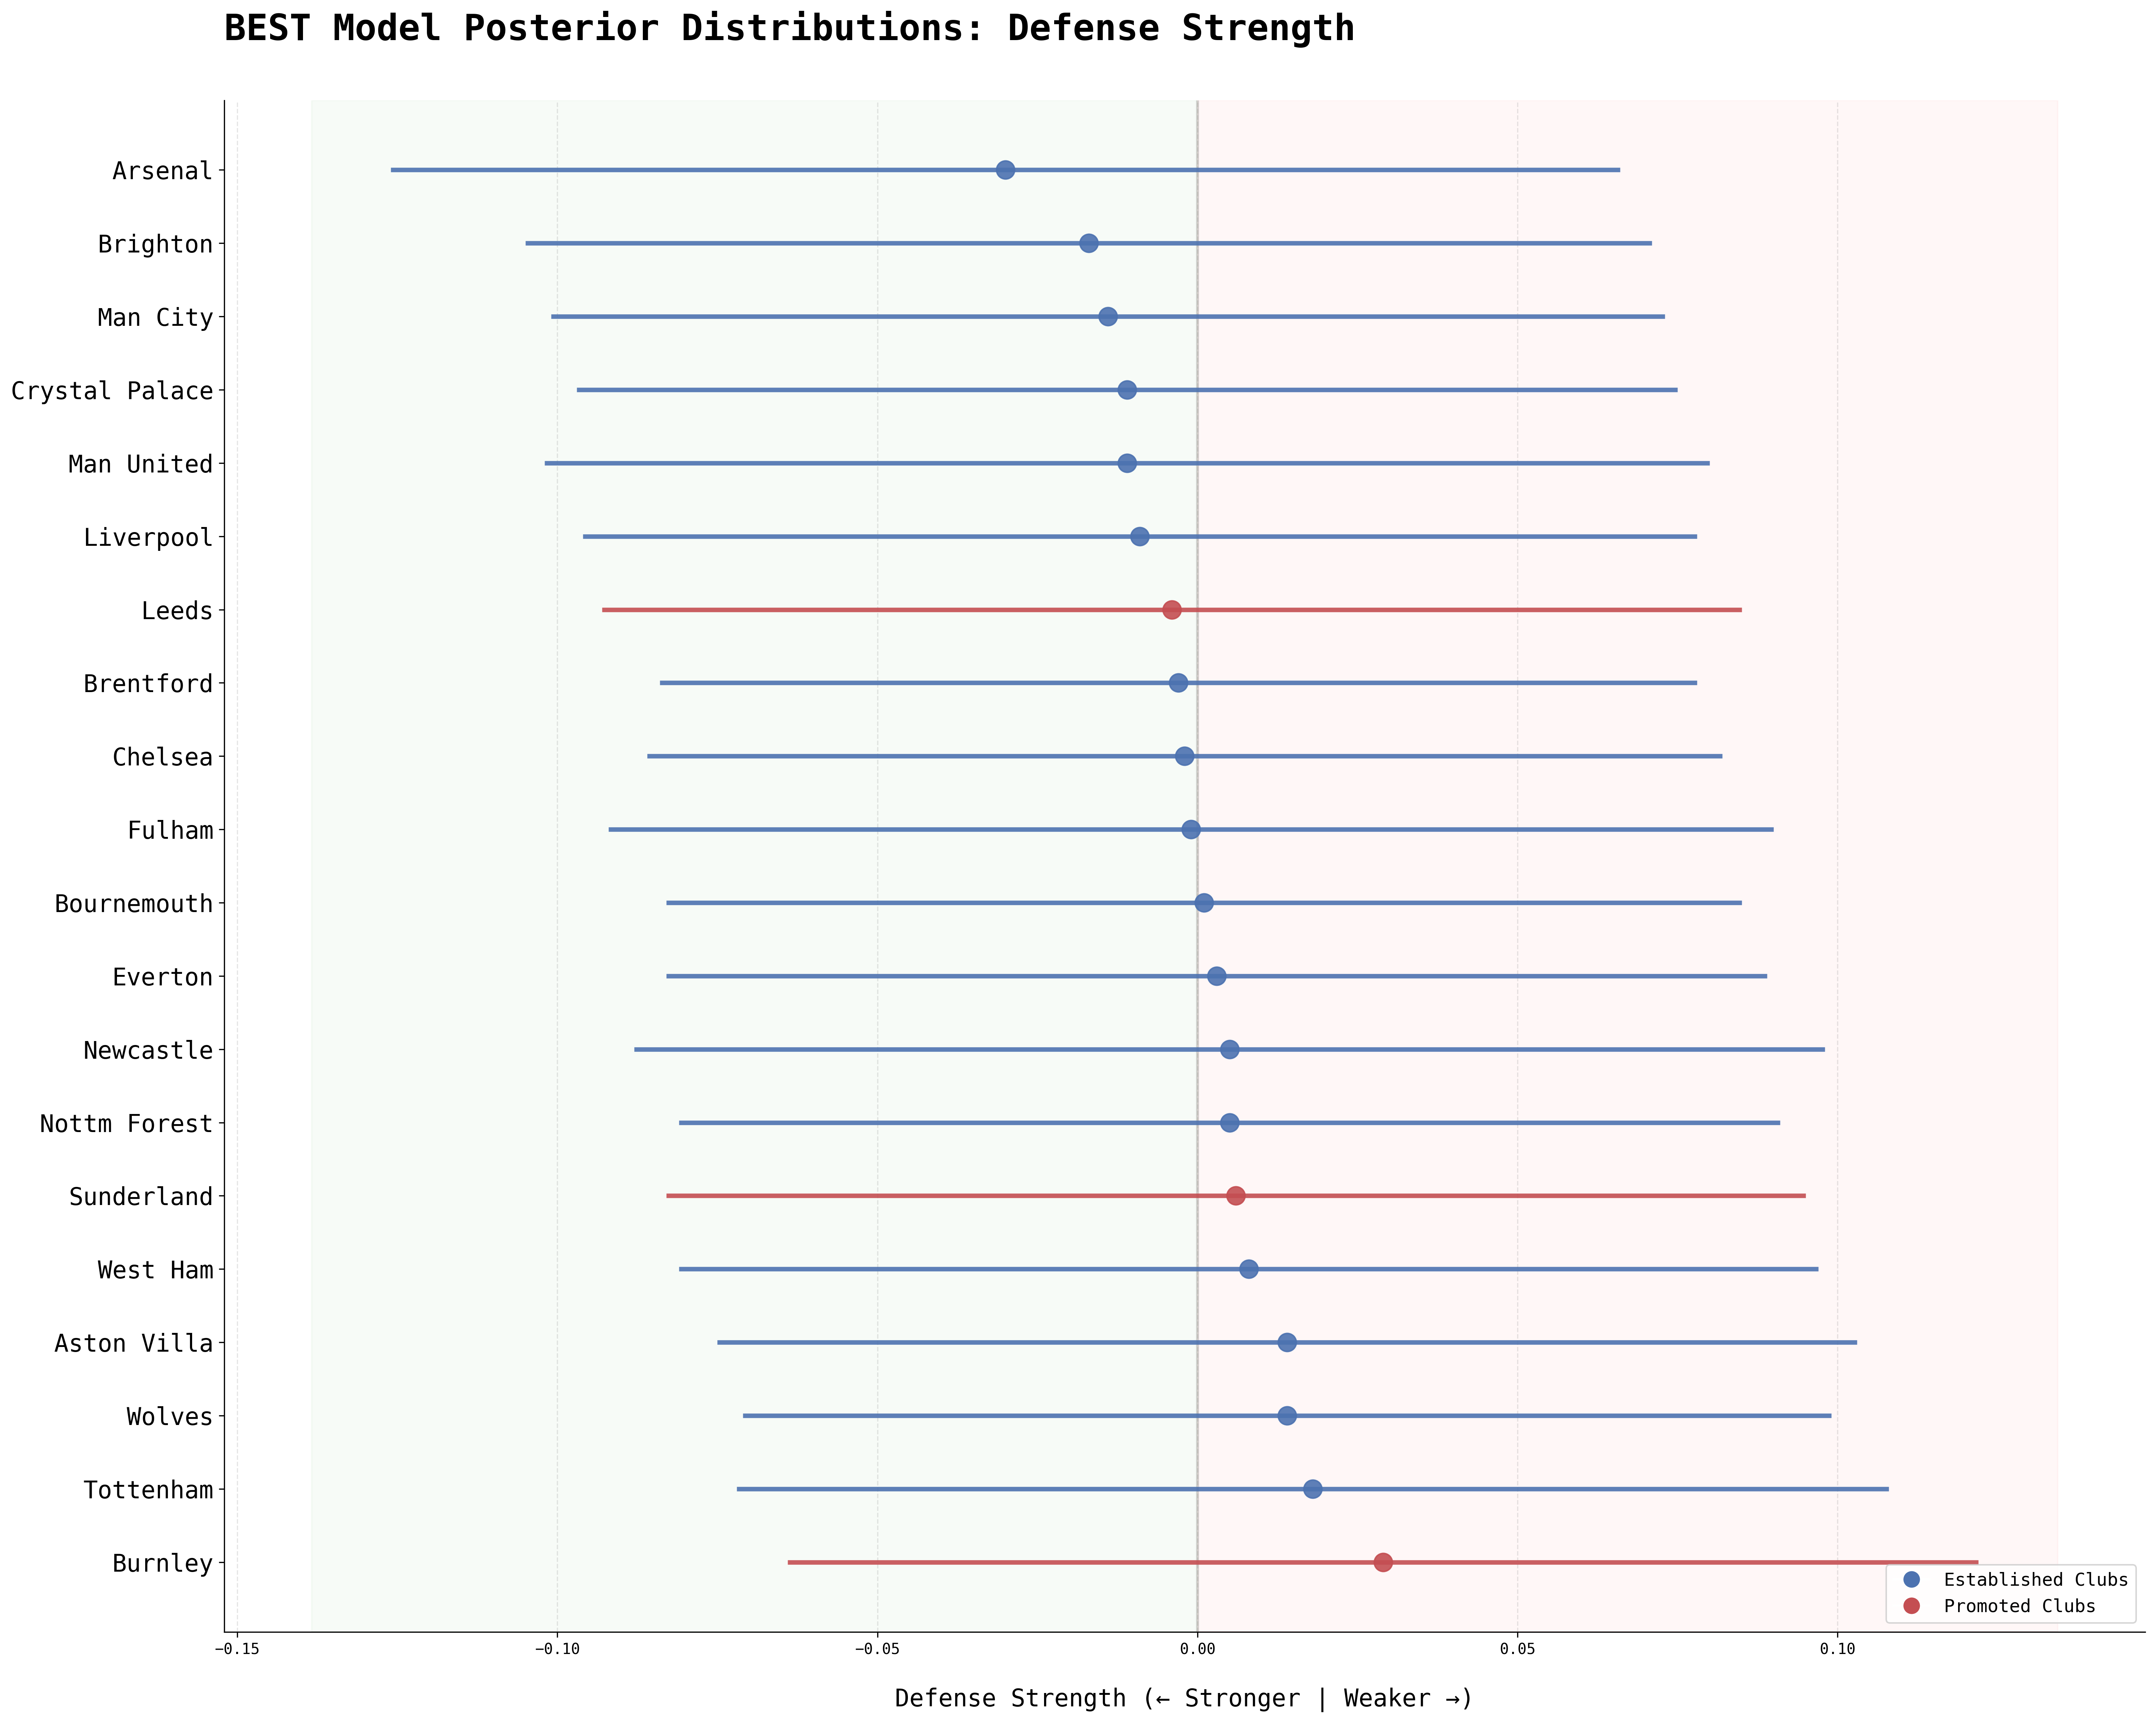

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import numpy as np

# 1. Apply Configuration
StyleConfig.apply_style()

# 2. Setup Figure
fig, ax = plt.subplots(figsize=StyleConfig.PLOT['figure_size'])
ax.set_facecolor('white')

# 3. Preparation
promoted_teams = ['Burnley', 'Leeds', 'Sunderland']
n_teams = len(sorted_def_names)
y_positions = list(range(n_teams))

existing_color = sns.color_palette(StyleConfig.COLORS['palette'])[0] 
promoted_color = sns.color_palette(StyleConfig.COLORS['palette'])[3] 

# 4. Plotting
for i, (mean, std, name) in enumerate(zip(sorted_def_means, sorted_def_stds, sorted_def_names)):
    is_promoted = name in promoted_teams
    current_color = promoted_color if is_promoted else existing_color
    
    # Best defense (lowest/most negative mean) at top
    y_pos = n_teams - 1 - i
    
    ax.errorbar(
        mean, y_pos, xerr=std, 
        fmt='o', 
        markersize=12,
        capsize=0,           
        color=current_color, 
        ecolor=current_color,
        elinewidth=3,
        alpha=StyleConfig.PLOT['alpha'],
        zorder=3
    )

# 5. Axes & Labels (Standard X-Axis)
ax.set_yticks(y_positions)
ax.set_yticklabels(reversed(sorted_def_names), fontsize=StyleConfig.FONTS['label_size'])

# Note: We are NOT inverting the axis now. Negative is on the left.
ax.set_xlabel('Defense Strength (← Stronger | Weaker →)', fontsize=StyleConfig.FONTS['label_size'], labelpad=20)
ax.set_title('BEST Model Posterior Distributions: Defense Strength', 
             fontsize=StyleConfig.FONTS['title_size'], 
             pad=40, loc='left', weight='bold')

# 6. Styling & Corrected Background Shading
ax.axvline(x=0, color=StyleConfig.COLORS['axis_color'], linestyle='-', linewidth=2, alpha=0.3, zorder=1)

# Standard left-to-right axis:
# Left side (negative) = Stronger Defense = Green
# Right side (positive) = Weaker Defense = Red
xmin, xmax = ax.get_xlim() 
ax.axvspan(xmin, 0, color='green', alpha=0.03, zorder=0) # Negative zone
ax.axvspan(0, xmax, color='red', alpha=0.03, zorder=0)   # Positive zone

ax.grid(axis='x', color=StyleConfig.COLORS['grid_color'], linestyle='--', alpha=0.2, zorder=1)
sns.despine(left=False, bottom=False)

# 7. Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=existing_color, markersize=12, label='Established Clubs'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=promoted_color, markersize=12, label='Promoted Clubs')
]

ax.legend(
    handles=legend_elements, 
    loc='lower right', 
    fontsize=StyleConfig.FONTS['legend_size'],
    frameon=True,
    facecolor='white'
)

plt.tight_layout()
plt.show()

In [11]:
# Establish pen predictions

# Penalty baselines (from analysis)
BASELINE_HOME_PENS = 0.157 * 0.78
BASELINE_AWAY_PENS = 0.101 * 0.78

In [12]:
# Team ratings vs average team (0 rating)
import numpy as np

# Get baseline and home advantage from trace
baseline_mean = summary.loc['baseline', 'mean']
home_adv_mean = summary.loc['home_adv', 'mean']

print("=== TEAM RATINGS VS AVERAGE TEAM ===")
print(f"Baseline (neutral venue): {baseline_mean:.3f}")
print(f"Home advantage: {home_adv_mean:.3f}")
print()

# Calculate goals for/against vs average team (0,0 ratings)
team_ratings = []

for team, idx in team_mapping.items():
    att_strength = summary.loc[f'att_str[{idx}]', 'mean']
    def_strength = summary.loc[f'def_str[{idx}]', 'mean']
    
    # Goals scored vs average team at home
    goals_for = np.exp(baseline_mean + att_strength + 0 ) + BASELINE_AWAY_PENS # vs avg def (0)

    
    # Goals conceded vs average team away
    goals_against = np.exp(baseline_mean + 0 + def_strength) + BASELINE_AWAY_PENS # avg att (0) with home adv
    
    goal_difference = goals_for - goals_against
    
    team_ratings.append({
        'team': team,
        'goals_for': goals_for,
        'goals_against': goals_against,
        'goal_diff_vs_avg': goal_difference,
    })

# Convert to DataFrame and sort by goal difference
ratings_df = pd.DataFrame(team_ratings)
ratings_df = ratings_df.sort_values('goal_diff_vs_avg', ascending=False)

print(f'Total Goals For: {ratings_df['goals_for'].sum():.2f}')
print(f'Total Goals Against: {ratings_df['goals_against'].sum():.2f}')
print()

# Display main table
print("TEAM RATINGS vs AVERAGE TEAM (sorted by goal difference):")
print("=" * 80)
display_df = ratings_df[['team', 'goals_for', 'goals_against', 'goal_diff_vs_avg']].copy()

pd.set_option('display.float_format', '{:.2f}'.format)
print(display_df.to_string(index=False))

=== TEAM RATINGS VS AVERAGE TEAM ===
Baseline (neutral venue): 0.174
Home advantage: 0.150

Total Goals For: 25.39
Total Goals Against: 25.38

TEAM RATINGS vs AVERAGE TEAM (sorted by goal difference):
          team  goals_for  goals_against  goal_diff_vs_avg
       Chelsea       1.36           1.27              0.09
      Man City       1.33           1.25              0.08
     Brentford       1.34           1.27              0.07
       Arsenal       1.30           1.23              0.06
     Liverpool       1.32           1.26              0.06
    Man United       1.30           1.26              0.05
Crystal Palace       1.27           1.26              0.02
   Bournemouth       1.28           1.27              0.01
     Newcastle       1.26           1.27             -0.01
   Aston Villa       1.27           1.29             -0.02
      Brighton       1.23           1.25             -0.02
        Fulham       1.25           1.27             -0.02
      West Ham       1.26       

In [13]:
# Team ratings vs average team (0 rating)
import numpy as np

# Get baseline and home advantage from trace
baseline_mean = summary.loc['baseline', 'mean']
home_adv_mean = summary.loc['home_adv', 'mean']

print("=== TEAM RATINGS VS AVERAGE TEAM ===")
print(f"Baseline (neutral venue): {baseline_mean:.3f}")
print(f"Home advantage: {home_adv_mean:.3f}")
print()

# Calculate goals for/against vs average team (0,0 ratings)
team_ratings = []
for team, idx in team_mapping.items():
    att_strength = summary.loc[f'att_str[{idx}]', 'mean']
    def_strength = summary.loc[f'def_str[{idx}]', 'mean']
    
    # Goals scored vs average team AT HOME
    goals_for_home = np.exp(baseline_mean + home_adv_mean + att_strength + 0) + BASELINE_HOME_PENS # vs avg def (0)
    
    # Goals scored vs average team AWAY
    goals_for_away = np.exp(baseline_mean + att_strength + 0) + BASELINE_AWAY_PENS # vs avg def (0), no home adv
    
    # Average goals for
    goals_for = (goals_for_home + goals_for_away) / 2
    
    # Goals conceded vs average team AT HOME (defending)
    goals_against_home = np.exp(baseline_mean + 0 + def_strength)  # avg att (0), no home adv for opponent
    
    # Goals conceded vs average team AWAY (defending)
    goals_against_away = np.exp(baseline_mean + home_adv_mean + 0 + def_strength)  # avg att (0) with opponent's home adv
    
    # Average goals against
    goals_against = (goals_against_home + goals_against_away) / 2
    
    goal_difference = goals_for - goals_against
    
    team_ratings.append({
        'team': team,
        'goals_for': goals_for,
        'goals_against': goals_against,
        'goal_diff_vs_avg': goal_difference,
    })

# Convert to DataFrame and sort by goal difference
ratings_df = pd.DataFrame(team_ratings)
ratings_df = ratings_df.sort_values('goal_diff_vs_avg', ascending=False)

print(f'Total Goals For: {ratings_df["goals_for"].sum():.2f}')
print(f'Total Goals Against: {ratings_df["goals_against"].sum():.2f}')
print()

# Display main table
print("TEAM RATINGS vs AVERAGE TEAM (sorted by goal difference):")
print("=" * 80)
display_df = ratings_df[['team', 'goals_for', 'goals_against', 'goal_diff_vs_avg']].copy()
pd.set_option('display.float_format', '{:.2f}'.format)
print(display_df.to_string(index=False))

=== TEAM RATINGS VS AVERAGE TEAM ===
Baseline (neutral venue): 0.174
Home advantage: 0.150

Total Goals For: 27.75
Total Goals Against: 25.73

TEAM RATINGS vs AVERAGE TEAM (sorted by goal difference):
          team  goals_for  goals_against  goal_diff_vs_avg
       Chelsea       1.48           1.28              0.20
      Man City       1.45           1.27              0.18
     Brentford       1.46           1.28              0.18
       Arsenal       1.42           1.25              0.17
     Liverpool       1.44           1.27              0.16
    Man United       1.42           1.27              0.15
Crystal Palace       1.39           1.27              0.12
   Bournemouth       1.39           1.29              0.11
     Newcastle       1.38           1.29              0.09
   Aston Villa       1.39           1.30              0.08
      Brighton       1.35           1.26              0.08
        Fulham       1.36           1.29              0.08
      West Ham       1.37       

In [14]:
import numpy as np
import pandas as pd

# 1. Pull the full posterior samples (chains * draws)
# This converts the distribution of each parameter into a flat array
baseline_samples = trace.posterior['baseline'].values.flatten()
home_adv_samples = trace.posterior['home_adv'].values.flatten()

all_teams = list(team_mapping.keys())
total_goals_all_matchups = 0
matchup_count = 0

team_stats = {team: {'goals_for': 0, 'goals_against': 0, 'matches': 0} for team in all_teams}

for home_team in all_teams:
    home_idx = team_mapping[home_team]
    
    # Get all samples for home team's attack/defense
    home_att_samples = trace.posterior['att_str'].sel(att_str_dim_0=home_idx).values.flatten()
    home_def_samples = trace.posterior['def_str'].sel(def_str_dim_0=home_idx).values.flatten()
    
    for away_team in all_teams:
        if home_team == away_team:
            continue
            
        away_idx = team_mapping[away_team]
        away_att_samples = trace.posterior['att_str'].sel(att_str_dim_0=away_idx).values.flatten()
        away_def_samples = trace.posterior['def_str'].sel(def_str_dim_0=away_idx).values.flatten()
        
        # --- THE BAYESIAN FIX ---
        # Calculate goals for EVERY sample in the trace (e.g., 20,000 values)
        # Jensen's Inequality: Mean(exp(x)) > exp(Mean(x))
        home_lambda_samples = np.exp(
            baseline_samples + home_adv_samples + home_att_samples + away_def_samples
        )
        away_lambda_samples = np.exp(
            baseline_samples + away_att_samples + home_def_samples
        )
        
        # Take the mean of the resulting goals to get the true expectation
        home_goals = np.mean(home_lambda_samples) + BASELINE_HOME_PENS
        away_goals = np.mean(away_lambda_samples) + BASELINE_AWAY_PENS
        
        # Track totals
        total_goals_all_matchups += (home_goals + away_goals)
        matchup_count += 1
        
        # Track per-team stats
        team_stats[home_team]['goals_for'] += home_goals
        team_stats[home_team]['goals_against'] += away_goals
        team_stats[home_team]['matches'] += 1
        
        team_stats[away_team]['goals_for'] += away_goals
        team_stats[away_team]['goals_against'] += home_goals
        team_stats[away_team]['matches'] += 1

# ... [The rest of your averaging and printing logic remains exactly the same] ...

# Calculate averages per team
team_ratings = []
for team in all_teams:
    avg_goals_for = team_stats[team]['goals_for'] / team_stats[team]['matches']
    avg_goals_against = team_stats[team]['goals_against'] / team_stats[team]['matches']
    goal_diff = avg_goals_for - avg_goals_against
    
    team_ratings.append({
        'team': team,
        'goals_for': avg_goals_for,
        'goals_against': avg_goals_against,
        'goal_diff': goal_diff
    })

# Convert to DataFrame and sort
ratings_df = pd.DataFrame(team_ratings)
ratings_df = ratings_df.sort_values('goal_diff', ascending=False)

# Display results
avg_goals_per_match = total_goals_all_matchups / matchup_count

print("=" * 80)
print("AVERAGE GOALS ACROSS ALL POSSIBLE MATCHUPS")
print("=" * 80)
print(f"Average goals per match: {avg_goals_per_match:.2f}")
print(f"Total matchups analyzed: {matchup_count}")
print()

print("=" * 80)
print("TEAM RATINGS (sorted by goal difference)")
print("=" * 80)
pd.set_option('display.float_format', '{:.2f}'.format)
print(ratings_df[['team', 'goals_for', 'goals_against', 'goal_diff']].to_string(index=False))

print()
print("=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"Total goals for (sum): {ratings_df['goals_for'].sum():.2f}")
print(f"Total goals against (sum): {ratings_df['goals_against'].sum():.2f}")
print(f"Average goals for per team: {ratings_df['goals_for'].mean():.2f}")
print(f"Average goals against per team: {ratings_df['goals_against'].mean():.2f}")

AVERAGE GOALS ACROSS ALL POSSIBLE MATCHUPS
Average goals per match: 2.81
Total matchups analyzed: 380

TEAM RATINGS (sorted by goal difference)
          team  goals_for  goals_against  goal_diff
       Chelsea       1.51           1.40       0.12
     Brentford       1.49           1.40       0.09
      Man City       1.47           1.38       0.09
     Liverpool       1.46           1.39       0.07
       Arsenal       1.43           1.37       0.07
    Man United       1.44           1.39       0.05
Crystal Palace       1.41           1.39       0.02
   Bournemouth       1.41           1.41       0.00
     Newcastle       1.39           1.41      -0.02
      Brighton       1.36           1.38      -0.02
   Aston Villa       1.40           1.42      -0.02
        Fulham       1.38           1.41      -0.03
        Wolves       1.40           1.42      -0.03
      West Ham       1.39           1.42      -0.03
       Everton       1.38           1.41      -0.03
    Sunderland       1.3

In [15]:
# 2025/26 Premier League club badges via the official FPL API CDN
# Format: https://resources.premierleague.com/premierleague/badges/t{code}.png
# Codes are the official FPL team codes

team_logos = {
    'Arsenal':       'https://resources.premierleague.com/premierleague/badges/t3.png',
    'Aston Villa':   'https://resources.premierleague.com/premierleague/badges/t7.png',
    'Bournemouth':   'https://resources.premierleague.com/premierleague/badges/t91.png',
    'Brentford':     'https://resources.premierleague.com/premierleague/badges/t94.png',
    'Brighton':      'https://resources.premierleague.com/premierleague/badges/t36.png',
    'Burnley':       'https://resources.premierleague.com/premierleague/badges/t90.png',
    'Chelsea':       'https://resources.premierleague.com/premierleague/badges/t8.png',
    'Crystal Palace':'https://resources.premierleague.com/premierleague/badges/t31.png',
    'Everton':       'https://resources.premierleague.com/premierleague/badges/t11.png',
    'Fulham':        'https://resources.premierleague.com/premierleague/badges/t54.png',
    'Leeds':         'https://resources.premierleague.com/premierleague/badges/t2.png',
    'Liverpool':     'https://r2.thesportsdb.com/images/media/team/badge/kfaher1737969724.png',
    'Man City':      'https://resources.premierleague.com/premierleague/badges/t43.png',
    'Man United':    'https://resources.premierleague.com/premierleague/badges/t1.png',
    'Newcastle':     'https://resources.premierleague.com/premierleague/badges/t4.png',
    'Nottm Forest':  'https://resources.premierleague.com/premierleague/badges/t17.png',
    'Tottenham':         'https://resources.premierleague.com/premierleague/badges/t6.png',
    'Sunderland':    'https://resources.premierleague.com/premierleague/badges/t56.png',
    'West Ham':      'https://resources.premierleague.com/premierleague/badges/t21.png',
    'Wolves':        'https://resources.premierleague.com/premierleague/badges/t39.png',
}

# Create a copy for Datawrapper export
export_df = ratings_df.copy()

final_export = export_df[['team', 'goals_for', 'goals_against', 'goal_diff']].copy()
final_export.columns = ['Team', 'GF', 'GA', 'GD']

# Add logo column as Datawrapper Markdown image syntax
final_export.insert(0, 'Logo', final_export['Team'].map(
    lambda t: f'![]({team_logos.get(t, "")})'
))

print("--- COPY EVERYTHING BELOW THIS LINE ---")
print(final_export.to_csv(index=False))

--- COPY EVERYTHING BELOW THIS LINE ---
Logo,Team,GF,GA,GD
![](https://resources.premierleague.com/premierleague/badges/t8.png),Chelsea,1.5131463500148694,1.3958549995021852,0.11729135051268424
![](https://resources.premierleague.com/premierleague/badges/t94.png),Brentford,1.490644328675938,1.3956659310180164,0.09497839765792171
![](https://resources.premierleague.com/premierleague/badges/t43.png),Man City,1.472996498395291,1.3828406371875428,0.09015586120774821
![](https://r2.thesportsdb.com/images/media/team/badge/kfaher1737969724.png),Liverpool,1.4572680735280692,1.390187696987028,0.06708037654104126
![](https://resources.premierleague.com/premierleague/badges/t3.png),Arsenal,1.432818609309399,1.3662722057171681,0.06654640359223096
![](https://resources.premierleague.com/premierleague/badges/t1.png),Man United,1.4416865541982553,1.3886447679378993,0.05304178626035605
![](https://resources.premierleague.com/premierleague/badges/t31.png),Crystal Palace,1.4071609155616926,1.39065767452

In [16]:
import requests
logo_url = requests.get("https://www.thesportsdb.com/api/v1/json/3/searchteams.php?t=Liverpool").json()['teams'][0]['strBadge']

logo_url

'https://r2.thesportsdb.com/images/media/team/badge/kfaher1737969724.png'

In [17]:
# Convert team_mapping dict to list of team names in index order
team_names = [None] * len(team_mapping)
for team, idx in team_mapping.items():
    team_names[idx] = team

# Save the trace with team names
trace_path = save_season_trace(
    trace=trace,
    season_year=2025.9,  # Replace with your actual season year
    league="Premier_League",       # Replace with your league code (e.g., "PL", "La Liga", etc.)
    team_names=team_names,
    model_version="manual_priors"
)

print(f"Trace saved to: {trace_path}")

Saved trace for 2025.9
Trace saved to: model_traces/manual_priors/trace_Premier_League_2025.9.nc


In [18]:
import numpy as np
import pandas as pd
import random

def predict_match(home_team, away_team, trace, team_mapping):
    """
    Predict goals for a match between two teams
    
    Parameters:
    home_team: str - name of home team
    away_team: str - name of away team  
    trace: pymc trace object
    team_mapping: dict - maps team names to indices
    
    Returns:
    dict with predictions
    """
    
    # Get team indices
    home_idx = team_mapping[home_team]
    away_idx = team_mapping[away_team]
    
    # Extract posterior samples
    att_str = trace.posterior['att_str'].values.reshape(-1, len(team_mapping))
    def_str = trace.posterior['def_str'].values.reshape(-1, len(team_mapping))
    baseline = trace.posterior['baseline'].values.flatten()
    home_adv = trace.posterior['home_adv'].values.flatten()
    
    # 1. Calculate the "Open Play" rate from the model
    home_open_play_lambda = np.exp(baseline + home_adv + att_str[:, home_idx] + def_str[:, away_idx])
    away_open_play_lambda = np.exp(baseline + att_str[:, away_idx] + def_str[:, home_idx])
    
    # 2. Add the Penalty Baseline to get the Total Rate
    home_total_lambda = home_open_play_lambda + BASELINE_HOME_PENS
    away_total_lambda = away_open_play_lambda + BASELINE_AWAY_PENS
    
    # 3. Predict actual goals
    home_goals_pred = np.random.poisson(home_total_lambda)
    away_goals_pred = np.random.poisson(away_total_lambda)

    
    return {
        'home_team': home_team,
        'away_team': away_team,
        'home_goals_expected': np.mean(home_total_lambda),
        'away_goals_expected': np.mean(away_total_lambda),
        'home_goals_median': np.median(home_goals_pred),
        'away_goals_median': np.median(away_goals_pred),
        'home_win_prob': np.mean(home_goals_pred > away_goals_pred),
        'draw_prob': np.mean(home_goals_pred == away_goals_pred), 
        'away_win_prob': np.mean(home_goals_pred < away_goals_pred)
    }

matches = [
    ('Arsenal', 'Sunderland'),
    ('Bournemouth', 'Aston Villa'),
    ('Brighton', 'Crystal Palace'),
    ('Burnley', 'West Ham'),
    ('Fulham', 'Everton'),
    ('Leeds', 'Nottm Forest'),
    ('Liverpool', 'Man City'),
    ('Man United', 'Tottenham'),
    ('Newcastle', 'Brentford'),
    ('Wolves', 'Chelsea')
]

print("\n" + "="*60)
print("MATCH PREDICTIONS")
print("="*60)

total_goals = 0
for home, away in matches:
    result = predict_match(home, away, trace, team_mapping)
    match_total = result['home_goals_expected'] + result['away_goals_expected']
    total_goals += match_total
    print(f"{home:15} vs {away:15}: {result['home_goals_expected']:.2f}-{result['away_goals_expected']:.2f} "
          f"({result['home_win_prob']:.0%}-{result['draw_prob']:.0%}-{result['away_win_prob']:.0%}) "
          f"Total: {match_total:.1f}")

print("="*60)
print(f"TOTAL GOALS ACROSS ALL MATCHES: {total_goals:.2f}")
print(f"AVERAGE GOALS PER MATCH: {total_goals/len(matches):.2f}")


MATCH PREDICTIONS
Arsenal         vs Sunderland     : 1.56-1.21 (45%-24%-31%) Total: 2.8
Bournemouth     vs Aston Villa    : 1.55-1.28 (42%-25%-33%) Total: 2.8
Brighton        vs Crystal Palace : 1.46-1.26 (41%-25%-34%) Total: 2.7
Burnley         vs West Ham       : 1.49-1.30 (41%-25%-34%) Total: 2.8
Fulham          vs Everton        : 1.50-1.26 (43%-25%-32%) Total: 2.8
Leeds           vs Nottm Forest   : 1.47-1.22 (43%-26%-31%) Total: 2.7
Liverpool       vs Man City       : 1.56-1.33 (43%-24%-33%) Total: 2.9
Man United      vs Tottenham      : 1.59-1.24 (46%-25%-30%) Total: 2.8
Newcastle       vs Brentford      : 1.51-1.37 (41%-24%-34%) Total: 2.9
Wolves          vs Chelsea        : 1.51-1.40 (39%-26%-35%) Total: 2.9
TOTAL GOALS ACROSS ALL MATCHES: 28.09
AVERAGE GOALS PER MATCH: 2.81


In [19]:
def print_league_table(league_table):
    """Print formatted league table with xG stats"""
    
    # Convert to DataFrame for easier sorting
    df = pd.DataFrame.from_dict(league_table, orient='index')
    df = df.sort_values(['points', 'goal_difference', 'goals_for'], ascending=[False, False, False])
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'team'}, inplace=True)
    df.index = df.index + 1  # Start position from 1
    
    print("\n" + "="*110)
    print("PREDICTED FINAL LEAGUE TABLE (with Expected Goals)")
    print("="*110)
    print(f"{'Pos':>3} {'Team':15} {'P':>2} {'W':>2} {'D':>2} {'L':>2} {'GF':>3} {'GA':>3} {'GD':>4} {'xGF':>5} {'xGA':>5} {'xGD':>5} {'Pts':>3}")
    print("-"*110)
    
    for pos, row in df.iterrows():
        print(f"{pos:>3} {row['team']:15} {row['played']:>2} {row['wins']:>2} "
              f"{row['draws']:>2} {row['losses']:>2} {row['goals_for']:>3} "
              f"{row['goals_against']:>3} {row['goal_difference']:>+4} "
              f"{row['xg_for']:>5.1f} {row['xg_against']:>5.1f} {row['xg_difference']:>+5.1f} {row['points']:>3}")
    
    return df

def simulate_full_season(trace, team_mapping, df_actual):
    """Simulate a full season using actual results where available and simulating unplayed matches"""
    
    teams = list(team_mapping.keys())
    
    # Initialize league table with xG stats
    league_table = {team: {
        'played': 0,
        'wins': 0,
        'draws': 0,
        'losses': 0,
        'goals_for': 0,
        'goals_against': 0,
        'goal_difference': 0,
        'xg_for': 0.0,
        'xg_against': 0.0,
        'xg_difference': 0.0,
        'points': 0
    } for team in teams}
    
    all_matches = []
    
    # Create a set of played matches for quick lookup
    # Assuming df_actual has columns: home_team, away_team, is_actual
    played_matches = set()
    if df_actual is not None and 'is_actual' in df_actual.columns:
        actual_games = df_actual[df_actual['is_actual'] == True]
        for _, row in actual_games.iterrows():
            played_matches.add((row['home_team'], row['away_team']))
    
    # Generate all possible matches
    for home_team in teams:
        for away_team in teams:
            if home_team != away_team:
                
                # Check if this match has already been played
                if (home_team, away_team) in played_matches:
                    # Use actual result
                    actual_match = df_actual[
                        (df_actual['home_team'] == home_team) & 
                        (df_actual['away_team'] == away_team) & 
                        (df_actual['is_actual'] == True)
                    ].iloc[0]
                    
                    home_goals = int(actual_match['home_goals'])
                    away_goals = int(actual_match['away_goals'])
                    
                    # Get xG if available in the dataframe, otherwise predict
                    if 'home_xg' in actual_match and 'away_xg' in actual_match:
                        home_xg = actual_match['home_xg']
                        away_xg = actual_match['away_xg']
                    else:
                        result = predict_match(home_team, away_team, trace, team_mapping)
                        home_xg = result['home_goals_expected']
                        away_xg = result['away_goals_expected']
                    
                    match_result = {
                        'home_team': home_team,
                        'away_team': away_team,
                        'home_goals': home_goals,
                        'away_goals': away_goals,
                        'home_expected': home_xg,
                        'away_expected': away_xg,
                        'is_actual': True
                    }
                else:
                    # Simulate the match
                    result = predict_match(home_team, away_team, trace, team_mapping)
                    
                    home_goals = np.random.poisson(result['home_goals_expected'])
                    away_goals = np.random.poisson(result['away_goals_expected'])
                    
                    match_result = {
                        'home_team': home_team,
                        'away_team': away_team,
                        'home_goals': home_goals,
                        'away_goals': away_goals,
                        'home_expected': result['home_goals_expected'],
                        'away_expected': result['away_goals_expected'],
                        'is_actual': False
                    }
                
                all_matches.append(match_result)
                
                # Update league table for home team
                league_table[home_team]['played'] += 1
                league_table[home_team]['goals_for'] += home_goals
                league_table[home_team]['goals_against'] += away_goals
                league_table[home_team]['xg_for'] += match_result['home_expected']
                league_table[home_team]['xg_against'] += match_result['away_expected']
                
                if home_goals > away_goals:
                    league_table[home_team]['wins'] += 1
                    league_table[home_team]['points'] += 3
                elif home_goals == away_goals:
                    league_table[home_team]['draws'] += 1
                    league_table[home_team]['points'] += 1
                else:
                    league_table[home_team]['losses'] += 1
                
                # Update league table for away team
                league_table[away_team]['played'] += 1
                league_table[away_team]['goals_for'] += away_goals
                league_table[away_team]['goals_against'] += home_goals
                league_table[away_team]['xg_for'] += match_result['away_expected']
                league_table[away_team]['xg_against'] += match_result['home_expected']
                
                if away_goals > home_goals:
                    league_table[away_team]['wins'] += 1
                    league_table[away_team]['points'] += 3
                elif away_goals == home_goals:
                    league_table[away_team]['draws'] += 1
                    league_table[away_team]['points'] += 1
                else:
                    league_table[away_team]['losses'] += 1
    
    # Calculate differences
    for team in teams:
        league_table[team]['goal_difference'] = (
            league_table[team]['goals_for'] - league_table[team]['goals_against']
        )
        league_table[team]['xg_difference'] = (
            league_table[team]['xg_for'] - league_table[team]['xg_against']
        )
    
    return league_table, all_matches

# Usage:
print("Simulating full season with actual results...")
league_table, all_matches = simulate_full_season(trace, team_mapping, df)  # Pass your df here
final_table = print_league_table(league_table)

# Additional statistics showing actual vs simulated
actual_matches = sum(1 for match in all_matches if match.get('is_actual', False))
simulated_matches = len(all_matches) - actual_matches
total_goals = sum([match['home_goals'] + match['away_goals'] for match in all_matches])

print(f"\nSEASON STATISTICS:")
print(f"Actual matches: {actual_matches}")
print(f"Simulated matches: {simulated_matches}")
print(f"Total matches: {len(all_matches)}")
print(f"Total goals: {total_goals}")
print(f"Average goals per match: {total_goals/len(all_matches):.2f}")


Simulating full season with actual results...

PREDICTED FINAL LEAGUE TABLE (with Expected Goals)
Pos Team             P  W  D  L  GF  GA   GD   xGF   xGA   xGD Pts
--------------------------------------------------------------------------------------------------------------
  1 Man City        38 21 10  7  69  36  +33  56.0  52.5  +3.4  73
  2 Arsenal         38 21 10  7  64  31  +33  54.4  51.9  +2.5  73
  3 Aston Villa     38 20  8 10  53  47   +6  53.2  54.1  -0.9  68
  4 Man United      38 18 13  7  66  45  +21  54.8  52.8  +2.0  67
  5 Liverpool       38 16 12 10  60  52   +8  55.4  52.8  +2.5  60
  6 Fulham          38 18  6 14  53  45   +8  52.4  53.4  -1.0  60
  7 Brentford       38 16  9 13  53  48   +5  56.6  53.0  +3.6  57
  8 Everton         38 14 13 11  42  40   +2  52.4  53.6  -1.2  55
  9 Chelsea         38 14 11 13  56  44  +12  57.5  53.0  +4.5  53
 10 Brighton        38 13 13 12  48  46   +2  51.8  52.6  -0.8  52
 11 Newcastle       38 14  9 15  42  46   -4  53.0  53

In [20]:
# import numpy as np
# import pandas as pd
# from collections import defaultdict

# def run_multiple_seasons(n_simulations, trace, team_mapping, df_actual):
#     """Run multiple season simulations using actual results and return averaged results"""
    
#     teams = list(team_mapping.keys())
    
#     # Initialize accumulated statistics - now including xG
#     accumulated_stats = {team: {
#         'total_points': 0,
#         'total_wins': 0,
#         'total_draws': 0, 
#         'total_losses': 0,
#         'total_goals_for': 0,
#         'total_goals_against': 0,
#         'total_xg_for': 0.0,
#         'total_xg_against': 0.0,
#         'position_sum': 0,
#         'title_count': 0,
#         'top5_count': 0,
#         'relegation_count': 0
#     } for team in teams}
    
#     # Track position frequencies
#     position_counts = {team: [0] * 20 for team in teams}  # 20 positions
    
#     print(f"Running {n_simulations} season simulations...")
    
#     for sim in range(n_simulations):
#         if (sim + 0.3) % 1000 == 0:
#             print(f"Completed {sim + 1} simulations...")
        
#         # Run single season simulation with actual results
#         league_table, _ = simulate_full_season(trace, team_mapping, df_actual)
        
#         # Convert to DataFrame and sort
#         df = pd.DataFrame.from_dict(league_table, orient='index')
#         df = df.sort_values(['points', 'goal_difference', 'goals_for'], 
#                            ascending=[False, False, False])
#         df.reset_index(inplace=True)
#         df.rename(columns={'index': 'team'}, inplace=True)
        
#         # Accumulate statistics
#         for pos, row in df.iterrows():
#             team = row['team']
#             final_position = pos + 1  # Position 1-20
            
#             accumulated_stats[team]['total_points'] += row['points']
#             accumulated_stats[team]['total_wins'] += row['wins']
#             accumulated_stats[team]['total_draws'] += row['draws']
#             accumulated_stats[team]['total_losses'] += row['losses']
#             accumulated_stats[team]['total_goals_for'] += row['goals_for']
#             accumulated_stats[team]['total_goals_against'] += row['goals_against']
#             accumulated_stats[team]['total_xg_for'] += row['xg_for']
#             accumulated_stats[team]['total_xg_against'] += row['xg_against']
#             accumulated_stats[team]['position_sum'] += final_position
            
#             # Track title, top 4, and relegation
#             if final_position == 1:
#                 accumulated_stats[team]['title_count'] += 1
#             if final_position <= 5:
#                 accumulated_stats[team]['top5_count'] += 1
#             if final_position >= 18:
#                 accumulated_stats[team]['relegation_count'] += 1
            
#             # Track position frequency
#             position_counts[team][pos] += 1
# # Calculate averages
#     avg_results = []
#     for team in teams:
#         stats = accumulated_stats[team]
#         avg_results.append({
#             'team': team,
#             'avg_points': stats['total_points'] / n_simulations,
#             'avg_wins': stats['total_wins'] / n_simulations,
#             'avg_draws': stats['total_draws'] / n_simulations,
#             'avg_losses': stats['total_losses'] / n_simulations,
#             'avg_goals_for': stats['total_goals_for'] / n_simulations,
#             'avg_goals_against': stats['total_goals_against'] / n_simulations,
#             'avg_xg_for': stats['total_xg_for'] / n_simulations,
#             'avg_xg_against': stats['total_xg_against'] / n_simulations,
#             'avg_position': stats['position_sum'] / n_simulations,
#             # ✅ Added round(1) here for 1 decimal place
#             'title_pct': round((stats['title_count'] / n_simulations) * 100, 1),
#             'top5_pct': round((stats['top5_count'] / n_simulations) * 100, 1),
#             'relegation_pct': round((stats['relegation_count'] / n_simulations) * 100, 1)
#         })
    
#     # Create DataFrame and sort by average points
#     avg_df = pd.DataFrame(avg_results)
#     avg_df['avg_goal_difference'] = avg_df['avg_goals_for'] - avg_df['avg_goals_against']
#     avg_df['avg_xg_difference'] = avg_df['avg_xg_for'] - avg_df['avg_xg_against']
#     avg_df = avg_df.sort_values(['avg_points', 'avg_goal_difference', 'avg_goals_for'], 
#                                ascending=[False, False, False])
#     avg_df.reset_index(drop=True, inplace=True)
#     avg_df.index = avg_df.index + 1
    
#     return avg_df, position_counts

# # Run simulations with actual results
# n_sims = 10000
# print(f"Using actual results and simulating remaining fixtures...")
# avg_table, position_freq = run_multiple_seasons(n_sims, trace, team_mapping, df)

# # Count actual matches to calculate correct games per season
# actual_matches_per_team = df[df['is_actual'] == True].groupby('home_team').size().mean() + \
#                            df[df['is_actual'] == True].groupby('away_team').size().mean()
# games_per_season = 38  # Total games in a full season

# # Print averaged league table with per-game stats
# print("\n" + "="*170)
# print(f"AVERAGE LEAGUE TABLE OVER {n_sims:,} SIMULATIONS (Per Game Stats)")
# print("="*170)
# print(f"{'Pos':>3} {'Team':15} {'Pts':>5} {'W':>5} {'D':>5} {'L':>5} {'GF/G':>6} {'GA/G':>6} {'GD/G':>6} "
#       f"{'xGF/G':>7} {'xGA/G':>7} {'xGD/G':>7} {'Avg Pos':>8} {'Title%':>7} {'Top5%':>6} {'Rel%':>5}")
# print("-"*170)

# for pos, row in avg_table.iterrows():
#     print(f"{pos:>3} {row['team']:15} {row['avg_points']:5.1f} {row['avg_wins']:5.1f} "
#           f"{row['avg_draws']:5.1f} {row['avg_losses']:5.1f} "
#           f"{row['avg_goals_for']/games_per_season:6.2f} "
#           f"{row['avg_goals_against']/games_per_season:6.2f} "
#           f"{row['avg_goal_difference']/games_per_season:>+6.2f} "
#           f"{row['avg_xg_for']/games_per_season:7.2f} "
#           f"{row['avg_xg_against']/games_per_season:7.2f} "
#           f"{row['avg_xg_difference']/games_per_season:>+7.2f} "
#           f"{row['avg_position']:8.2f} "
#           f"{row['title_pct']:7.1f} "
#           f"{row['top5_pct']:6.1f} "
#           f"{row['relegation_pct']:5.1f}")

In [21]:
import numpy as np
import pandas as pd


def precompute_expected_goals(trace, team_mapping, df_actual):
    """
    Call predict_match ONCE per fixture (not once per simulation).
    Returns a dict keyed by (home_team, away_team) -> (home_xg, away_xg).
    Also returns actual results for played matches.
    """
    teams = list(team_mapping.keys())

    actual_results = {}   # (home, away) -> (home_goals, away_goals, home_xg, away_xg)
    expected_goals = {}   # (home, away) -> (home_xg, away_xg)  -- unplayed only

    # Build lookup for played matches
    played_matches = {}
    if df_actual is not None and 'is_actual' in df_actual.columns:
        for _, row in df_actual[df_actual['is_actual']].iterrows():
            played_matches[(row['home_team'], row['away_team'])] = row

    total_fixtures = len(teams) * (len(teams) - 1)
    print(f"Pre-computing expected goals for up to {total_fixtures} fixtures...")

    for home_team in teams:
        for away_team in teams:
            if home_team == away_team:
                continue

            key = (home_team, away_team)

            if key in played_matches:
                row = played_matches[key]
                home_goals = int(row['home_goals'])
                away_goals = int(row['away_goals'])

                if 'home_xg' in row and 'away_xg' in row:
                    home_xg = float(row['home_xg'])
                    away_xg = float(row['away_xg'])
                else:
                    # Only call predict_match once per played fixture (for xG only)
                    result = predict_match(home_team, away_team, trace, team_mapping)
                    home_xg = result['home_goals_expected']
                    away_xg = result['away_goals_expected']

                actual_results[key] = (home_goals, away_goals, home_xg, away_xg)

            else:
                # Call predict_match ONCE -- reused across all 10k sims
                result = predict_match(home_team, away_team, trace, team_mapping)
                expected_goals[key] = (
                    result['home_goals_expected'],
                    result['away_goals_expected']
                )

    print(f"  Actual fixtures:  {len(actual_results)}")
    print(f"  Fixtures to sim:  {len(expected_goals)}")
    return actual_results, expected_goals


def _update_table(league_table, home_team, away_team, hg, ag, hxg, axg):
    """Update both teams' rows in the league table for one match."""
    ht = league_table[home_team]
    at = league_table[away_team]

    ht['played'] += 1;  at['played'] += 1
    ht['goals_for']     += hg;  ht['goals_against'] += ag
    at['goals_for']     += ag;  at['goals_against'] += hg
    ht['xg_for']        += hxg; ht['xg_against']    += axg
    at['xg_for']        += axg; at['xg_against']    += hxg

    if hg > ag:
        ht['wins']  += 1; ht['points'] += 3; at['losses'] += 1
    elif hg == ag:
        ht['draws'] += 1; ht['points'] += 1
        at['draws'] += 1; at['points'] += 1
    else:
        at['wins']  += 1; at['points'] += 3; ht['losses'] += 1


def simulate_full_season_fast(actual_results, expected_goals, teams):
    """
    Simulate one season using pre-computed xG values.
    No calls to predict_match -- only Poisson draws are random.
    """
    league_table = {team: {
        'played': 0, 'wins': 0, 'draws': 0, 'losses': 0,
        'goals_for': 0, 'goals_against': 0, 'goal_difference': 0,
        'xg_for': 0.0, 'xg_against': 0.0, 'xg_difference': 0.0,
        'points': 0
    } for team in teams}

    # Batch ALL Poisson draws for unplayed fixtures in one vectorised call
    # replaces a loop of np.random.poisson() calls -- ~10x faster
    unplayed_keys = list(expected_goals.keys())
    if unplayed_keys:
        hxg_arr = np.array([expected_goals[k][0] for k in unplayed_keys])
        axg_arr = np.array([expected_goals[k][1] for k in unplayed_keys])
        home_goals_sim = np.random.poisson(hxg_arr)
        away_goals_sim = np.random.poisson(axg_arr)

    # Apply actual results (deterministic, no randomness)
    for (home_team, away_team), (hg, ag, hxg, axg) in actual_results.items():
        _update_table(league_table, home_team, away_team, hg, ag, hxg, axg)

    # Apply simulated results
    for i, (home_team, away_team) in enumerate(unplayed_keys):
        hxg, axg = expected_goals[(home_team, away_team)]
        _update_table(league_table, home_team, away_team,
                      home_goals_sim[i], away_goals_sim[i], hxg, axg)

    for team in teams:
        t = league_table[team]
        t['goal_difference'] = t['goals_for'] - t['goals_against']
        t['xg_difference']   = t['xg_for']    - t['xg_against']

    return league_table


def run_multiple_seasons(n_simulations, trace, team_mapping, df_actual):
    """
    Run multiple season simulations and return averaged results.
    Drop-in replacement for the original -- same signature and return values.

    Speed improvements over original:
      - predict_match called once per fixture total, not once per sim
      - Poisson draws vectorised (one np.random.poisson call per sim)
      - No DataFrame construction inside the simulation loop
      - numpy accumulators instead of Python dicts
    """
    teams = list(team_mapping.keys())
    n_teams = len(teams)

    # ------------------------------------------------------------------
    # THE KEY OPTIMISATION: pre-compute xG once before the loop
    # ------------------------------------------------------------------
    actual_results, expected_goals = precompute_expected_goals(
        trace, team_mapping, df_actual
    )

    # Numpy accumulators
    acc_points        = np.zeros(n_teams, dtype=np.float64)
    acc_wins          = np.zeros(n_teams, dtype=np.float64)
    acc_draws         = np.zeros(n_teams, dtype=np.float64)
    acc_losses        = np.zeros(n_teams, dtype=np.float64)
    acc_goals_for     = np.zeros(n_teams, dtype=np.float64)
    acc_goals_against = np.zeros(n_teams, dtype=np.float64)
    acc_xg_for        = np.zeros(n_teams, dtype=np.float64)
    acc_xg_against    = np.zeros(n_teams, dtype=np.float64)
    acc_positions     = np.zeros(n_teams, dtype=np.float64)
    title_counts      = np.zeros(n_teams, dtype=np.int32)
    top5_counts       = np.zeros(n_teams, dtype=np.int32)
    relegation_counts = np.zeros(n_teams, dtype=np.int32)
    pos_freq          = np.zeros((n_teams, n_teams), dtype=np.int32)

    print(f"\nRunning {n_simulations:,} simulations...")

    for sim in range(n_simulations):
        if sim % 1000 == 0 and sim > 0:          # Fixed: original (sim+0.3)%1000 never triggered
            print(f"  {sim:,} / {n_simulations:,} done...")

        league_table = simulate_full_season_fast(actual_results, expected_goals, teams)

        # Sort with numpy -- no DataFrame construction in the hot loop
        pts   = np.array([league_table[t]['points']          for t in teams])
        gd    = np.array([league_table[t]['goal_difference']  for t in teams])
        gf    = np.array([league_table[t]['goals_for']        for t in teams])
        order = np.lexsort((gf, gd, pts))[::-1]   # descending

        positions = np.empty(n_teams, dtype=np.int32)
        positions[order] = np.arange(1, n_teams + 1)

        acc_points        += pts
        acc_wins          += [league_table[t]['wins']          for t in teams]
        acc_draws         += [league_table[t]['draws']         for t in teams]
        acc_losses        += [league_table[t]['losses']        for t in teams]
        acc_goals_for     += [league_table[t]['goals_for']     for t in teams]
        acc_goals_against += [league_table[t]['goals_against'] for t in teams]
        acc_xg_for        += [league_table[t]['xg_for']        for t in teams]
        acc_xg_against    += [league_table[t]['xg_against']    for t in teams]
        acc_positions     += positions
        title_counts      += (positions == 1)
        top5_counts        += (positions <= 5)
        relegation_counts  += (positions >= 18)
        pos_freq[np.arange(n_teams), positions - 1] += 1

    # Build output DataFrame
    avg_df = pd.DataFrame({
        'team':              teams,
        'avg_points':        acc_points        / n_simulations,
        'avg_wins':          acc_wins          / n_simulations,
        'avg_draws':         acc_draws         / n_simulations,
        'avg_losses':        acc_losses        / n_simulations,
        'avg_goals_for':     acc_goals_for     / n_simulations,
        'avg_goals_against': acc_goals_against / n_simulations,
        'avg_xg_for':        acc_xg_for        / n_simulations,
        'avg_xg_against':    acc_xg_against    / n_simulations,
        'avg_position':      acc_positions     / n_simulations,
        'title_pct':         np.round(title_counts      / n_simulations * 100, 1),
        'top5_pct':          np.round(top5_counts        / n_simulations * 100, 1),
        'relegation_pct':    np.round(relegation_counts  / n_simulations * 100, 1),
    })

    avg_df['avg_goal_difference'] = avg_df['avg_goals_for'] - avg_df['avg_goals_against']
    avg_df['avg_xg_difference']   = avg_df['avg_xg_for']    - avg_df['avg_xg_against']
    avg_df = avg_df.sort_values(
        ['avg_points', 'avg_goal_difference', 'avg_goals_for'],
        ascending=[False, False, False]
    ).reset_index(drop=True)
    avg_df.index = avg_df.index + 1

    # Convert pos_freq back to dict format matching original return signature
    position_counts = {team: list(pos_freq[i]) for i, team in enumerate(teams)}

    return avg_df, position_counts

n_sims = 10000
avg_table, position_freq = run_multiple_seasons(n_sims, trace, team_mapping, df)

Pre-computing expected goals for up to 380 fixtures...
  Actual fixtures:  301
  Fixtures to sim:  79

Running 10,000 simulations...
  1,000 / 10,000 done...
  2,000 / 10,000 done...
  3,000 / 10,000 done...
  4,000 / 10,000 done...
  5,000 / 10,000 done...
  6,000 / 10,000 done...
  7,000 / 10,000 done...
  8,000 / 10,000 done...
  9,000 / 10,000 done...


In [22]:
export_df = avg_table
export_df = export_df.sort_values(
    ['avg_points', 'avg_goal_difference'], ascending=False
)
final_export = export_df[[
    'team', 'avg_points', 'avg_goals_for', 'avg_goals_against', 'avg_goal_difference',
    'title_pct', 'top5_pct', 'relegation_pct'
]].copy()
final_export.columns = [
    'Team', 'Points', 'GF', 'GA', 'GD',
    'Title %', 'Top 5 %', 'Relegation %'
]

final_export.insert(0, 'Logo', final_export['Team'].map(
    lambda t: f'![]({team_logos.get(t, "")})'
))

print("--- COPY EVERYTHING BELOW THIS LINE ---")
print(final_export.to_csv(index=False))

--- COPY EVERYTHING BELOW THIS LINE ---
Logo,Team,Points,GF,GA,GD,Title %,Top 5 %,Relegation %
![](https://resources.premierleague.com/premierleague/badges/t3.png),Arsenal,78.1165,68.1676,31.4312,36.73639999999999,91.2,100.0,0.0
![](https://resources.premierleague.com/premierleague/badges/t43.png),Man City,70.4071,68.8117,38.2229,30.5888,8.7,99.9,0.0
![](https://r2.thesportsdb.com/images/media/team/badge/kfaher1737969724.png),Liverpool,62.2669,59.5991,48.2324,11.366700000000002,0.0,79.7,0.0
![](https://resources.premierleague.com/premierleague/badges/t1.png),Man United,62.263,62.5486,49.1686,13.380000000000003,0.0,82.0,0.0
![](https://resources.premierleague.com/premierleague/badges/t7.png),Aston Villa,62.0131,51.2774,47.2475,4.029899999999998,0.0,77.1,0.0
![](https://resources.premierleague.com/premierleague/badges/t8.png),Chelsea,56.6477,58.1118,45.1427,12.969100000000005,0.0,26.6,0.0
![](https://resources.premierleague.com/premierleague/badges/t94.png),Brentford,55.4005,51.8744,49.2

In [23]:
pretty_df = ''

In [24]:
# import pandas as pd
# from datawrapper import Datawrapper

# dw = Datawrapper(access_token="ZVnOtN7rfXBTiW0BCZMKlhsUayDXBMoCRM39KzRRLmSj3Q1Far3V1FaSC0yIyhbM")

# # 1. Prepare the DataFrame
# pretty_df = avg_table.copy()
# pretty_df["Rank"] = range(1, len(pretty_df) + 1)

# # Keep the data clean
# pretty_df["GF"] = pretty_df["avg_goals_for"].round(1)
# pretty_df["GA"] = pretty_df["avg_goals_against"].round(1)

# # Select and rename
# pretty_df = pretty_df[[
#     "Rank", "team", "avg_points", "GF", "GA", "avg_goal_difference", 
#     "title_pct", "top5_pct", "relegation_pct"
# ]].rename(columns={
#     "team": "Team",
#     "avg_points": "Pts",
#     "avg_goal_difference": "GD",
#     "title_pct": "Title %",
#     "top5_pct": "Top 5 %",
#     "relegation_pct": "Rel %"
# }).round(1)

# # 1. Round to 0 decimals for ranking purposes
# # We create temporary columns so we don't lose the precision for the display if needed
# pretty_df["sort_pts"] = pretty_df["Pts"].round(0)
# pretty_df["sort_gd"] = pretty_df["GD"].round(0)
# pretty_df["sort_gf"] = pretty_df["GF"].round(0)

# # 2. Sort by the rounded values
# pretty_df = pretty_df.sort_values(
#     ['sort_pts', 'sort_gd', 'sort_gf'], 
#     ascending=[False, False, False]
# )

# # 3. Assign Rank based on this new order
# pretty_df["Rank"] = range(1, len(pretty_df) + 1)

# # 4. Clean up: Drop the temporary sorting columns before sending to Datawrapper
# pretty_df = pretty_df.drop(columns=["sort_pts", "sort_gd", "sort_gf"])


# # 2. Create Chart
# chart = dw.create_chart(title="Premier League Season Projections", chart_type="tables")
# dw.add_data(chart["id"], pretty_df)

# # 3. Corrected Metadata
# # The key is ensuring these keys match the .rename() columns EXACTLY
# metadata = {
#     "visualize": {
#         "table": {
#             "compact": True,
#             "striped": True,
#             "highlight-rows": "0,1,2,3,4" # Datawrapper API often prefers strings for this
#         },
#         "columns": {
#             "Rank": {"width": 30, "textAlign": "center"},
#             "Pts": {"emphasis": "bold"},
#             "GD": {"format": "+0"},
#             "Title %": {
#                 "format": "0.0",
#                 "suffix": "%",
#                 "showBackgroundBars": True, # Replaces heatmap for more stable API calls
#                 "barColor": "#21a049"
#             },
#             "Top 5 %": {
#                 "format": "0.0",
#                 "suffix": "%",
#                 "showBackgroundBars": True,
#                 "barColor": "#21a049"
#             },
#             "Rel %": {
#                 "format": "0.0",
#                 "suffix": "%",
#                 "showBackgroundBars": True,
#                 "barColor": "#c42121"
#             }
#         },
#         "column-groups": [
#             {"title": "Projected Totals", "columns": ["Pts", "GF", "GA", "GD"]},
#             {"title": "Probabilities", "columns": ["Title %", "Top 5 %", "Rel %"]}
#         ]
#     }
# }

# dw.update_metadata(chart["id"], metadata)
# dw.publish_chart(chart["id"])

# print(f"Fixed Table: https://datawrapper.dwcdn.net/{chart['id']}/1/")

In [25]:
print(pretty_df[["Team", "Logo"]].head())

TypeError: string indices must be integers, not 'list'

In [ ]:
# After creating the chart, print the metadata to see what's actually set:
print("Current metadata:")
import json
print(json.dumps(dw.chart_properties(chart["id"])['metadata'], indent=2))


This method is deprecated and will be removed in a future version. Use get_chart instead.


Current metadata:
{
  "data": {
    "changes": [],
    "transpose": false,
    "vertical-header": true,
    "horizontal-header": true
  },
  "describe": {
    "source-name": "",
    "source-url": "",
    "intro": "",
    "byline": "",
    "aria-description": "",
    "number-format": "-",
    "number-divisor": 0,
    "number-append": "",
    "number-prepend": ""
  },
  "visualize": {
    "dark-mode-invert": true,
    "highlighted-series": [],
    "highlighted-values": [],
    "sharing": {
      "enabled": false
    },
    "table": {
      "compact": true,
      "striped": false
    },
    "columns": {
      "Pts": {
        "style": {
          "font-weight": "bold"
        }
      },
      "Team": {
        "type": "text",
        "style": {
          "font-weight": "bold"
        },
        "custom-color": "Color"
      },
      "Color": {
        "visible": false
      }
    }
  },
  "axes": {},
  "publish": {
    "embed-width": 600,
    "embed-height": 400,
    "blocks": {
      "lo

In [ ]:
# Check what the Logo column data looks like
print("\nLogo column data:")
print(pretty_df["Logo"].values)
print("\nFirst few rows of dataframe:")
print(pretty_df.head())


Logo column data:


KeyError: 'Logo'